In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('Ass.csv')
df.head()


,Day,Outlook,Temp,Humidity(%),Wind,PlayTennis,Temp_Category,Humidity_Category
0,D1,Sunny,38,82,Weak,No,Hot,High
1,D2,Sunny,37,87,Strong,No,Hot,High
2,D3,Overcast,35,90,Weak,Yes,Hot,High
3,D4,Rain,25,75,Weak,Yes,Cool,High
4,D5,Rain,20,56,Weak,Yes,Cool,Normal


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Day                615 non-null    str  
 1   Outlook            615 non-null    str  
 2   Temp               615 non-null    int64
 3   Humidity(%)        615 non-null    int64
 4   Wind               615 non-null    str  
 5   PlayTennis         615 non-null    str  
 6   Temp_Category      615 non-null    str  
 7   Humidity_Category  615 non-null    str  
dtypes: int64(2), str(6)
memory usage: 38.6 KB


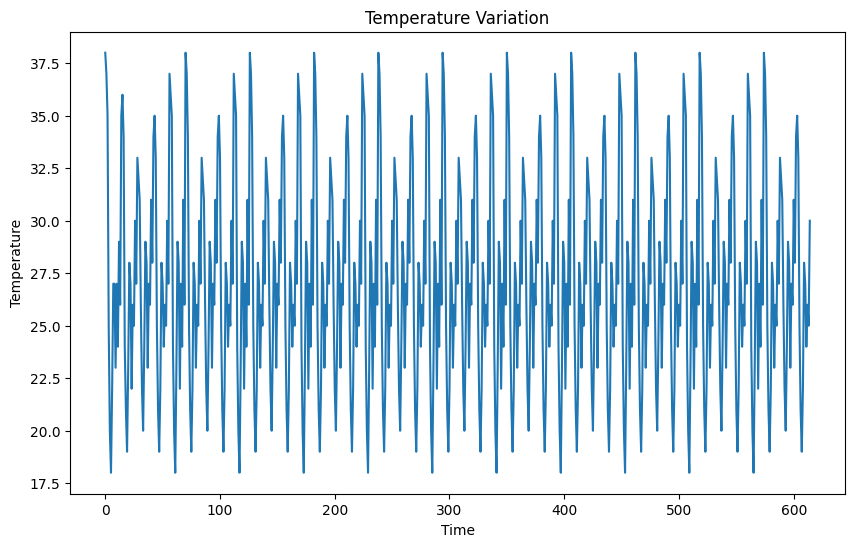

In [24]:
#data vizualization temparature

plt.figure(figsize=(10, 6))
plt.plot(df['Temp'])
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("Temperature Variation")
plt.show()





In [25]:
# in df dataset for Temp from 18-25 low 25-31 mid and 31-38 high
df['Temp_Category'] = pd.cut(df['Temp'], bins=[18, 25, 31, 38], labels=['Low', 'Mid', 'High'])
#for Humidity 21-53 low 53-84 mid 84-117 high
df['Humidity_Category'] = pd.cut(df['Humidity(%)'], bins=[21, 53, 84, 117], labels=['Low', 'Mid', 'High'])
df=df.drop(['Humidity(%)','Temp'],axis=1)

df.head()

,Day,Outlook,Wind,PlayTennis,Temp_Category,Humidity_Category
0,D1,Sunny,Weak,No,High,Mid
1,D2,Sunny,Strong,No,High,High
2,D3,Overcast,Weak,Yes,High,High
3,D4,Rain,Weak,Yes,Low,Mid
4,D5,Rain,Weak,Yes,Low,Mid


In [26]:
#use label encoder to encode all features except Day


from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
#use for loop

for col in df.columns:
    if col != 'Day':
        df[col] = le.fit_transform(df[col])

df=df.drop(['Day'],axis=1)

df.head()

,Outlook,Wind,PlayTennis,Temp_Category,Humidity_Category
0,2,1,0,0,2
1,2,0,0,0,0
2,0,1,1,0,0
3,1,1,1,1,2
4,1,1,1,1,2


In [27]:
#trainTest split
from sklearn.model_selection import train_test_split
X = df.drop('PlayTennis', axis=1)
y = df['PlayTennis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [29]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(y_pred)


[1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 0 1 0 1 1 0 1 1 1 0 1 1 1 0 1 1 0 0 1
 0 0 1 1 1 1 1 0 0 1 1 1 0 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 0 0
 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 1 1 1 0 1 1 1 0]


In [30]:
print("Accuracy:", rf.score(X_test, y_test))

Accuracy: 0.975609756097561
